In [1]:
import pandas as pd

df = pd.read_csv("bike_sharing_hourly.csv")
(df['casual'] + df['registered'] == df['cnt']).mean()


np.float64(1.0)

In [2]:
df[['casual', 'registered', 'cnt']].describe()

,casual,registered,cnt
count,17379.000000,17379.000000,17379.000000
mean,35.676218,153.786869,189.463088
std,49.305030,151.357286,181.387599
min,0.000000,0.000000,1.000000
25%,4.000000,34.000000,40.000000
50%,17.000000,115.000000,142.000000
75%,48.000000,220.000000,281.000000
max,367.000000,886.000000,977.000000


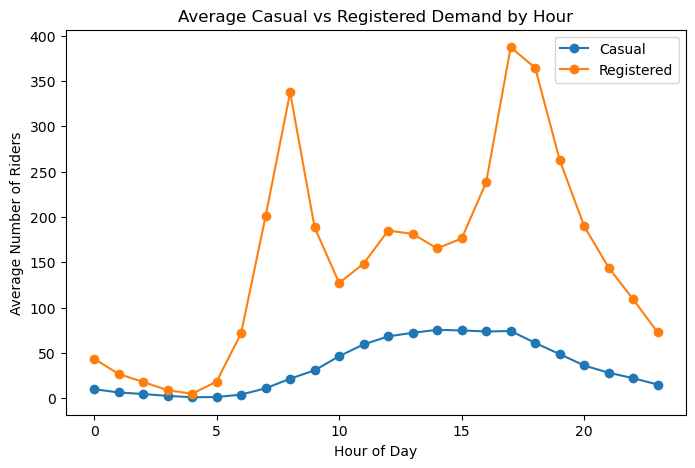

In [3]:
import matplotlib.pyplot as plt

hourly_avg = df.groupby('hr')[['casual', 'registered']].mean()

plt.figure(figsize=(8,5))
plt.plot(hourly_avg.index, hourly_avg['casual'], marker='o', label='Casual')
plt.plot(hourly_avg.index, hourly_avg['registered'], marker='o', label='Registered')
plt.xlabel('Hour of Day')
plt.ylabel('Average Number of Riders')
plt.title('Average Casual vs Registered Demand by Hour')
plt.legend()
plt.show()

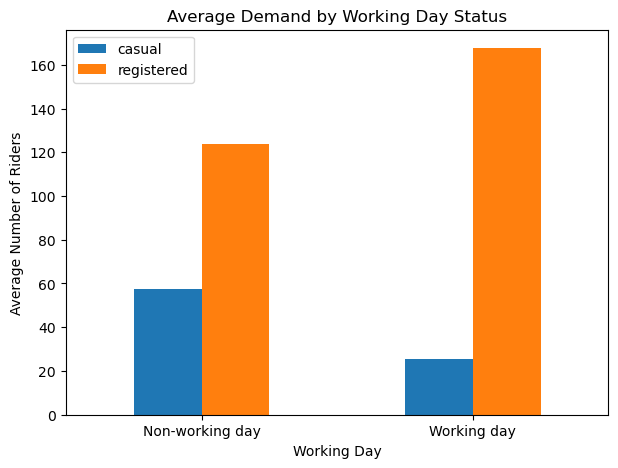

In [4]:
work_avg = df.groupby('workingday')[['casual', 'registered']].mean()

work_avg
work_avg.plot(kind='bar', figsize=(7,5))
plt.xlabel('Working Day')
plt.ylabel('Average Number of Riders')
plt.title('Average Demand by Working Day Status')
plt.xticks([0,1], ['Non-working day', 'Working day'], rotation=0)
plt.show()

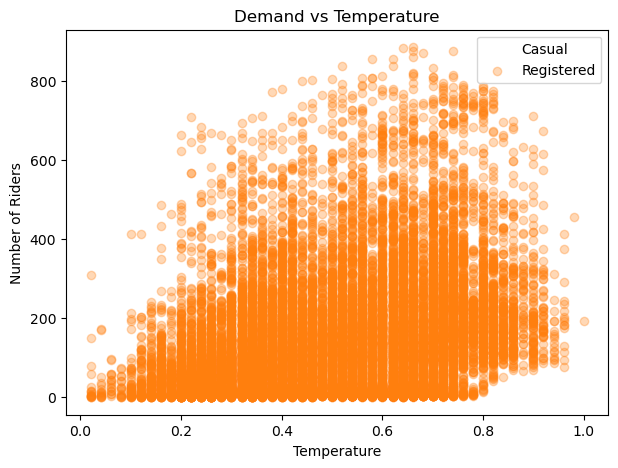

In [5]:
plt.figure(figsize=(7,5))
plt.scatter(df['temp'], df['casual'], alpha=0., label='Casual')
plt.scatter(df['temp'], df['registered'], alpha=0.3, label='Registered')
plt.xlabel('Temperature')
plt.ylabel('Number of Riders')
plt.title('Demand vs Temperature')
plt.legend()
plt.show()

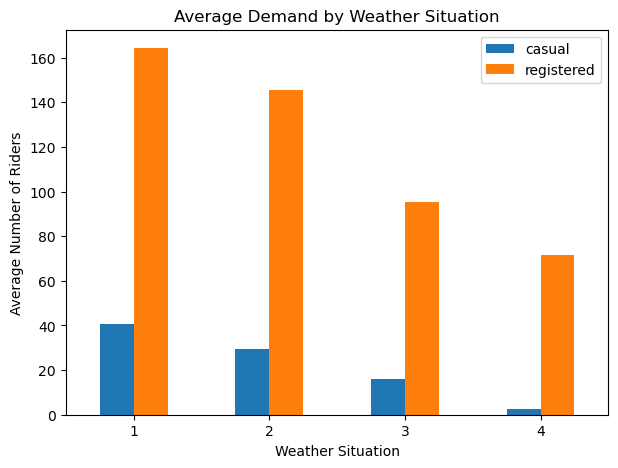

In [6]:
weather_avg = df.groupby('weathersit')[['casual', 'registered']].mean()

weather_avg.plot(kind='bar', figsize=(7,5))
plt.xlabel('Weather Situation')
plt.ylabel('Average Number of Riders')
plt.title('Average Demand by Weather Situation')
plt.xticks(rotation=0)
plt.show()

In [7]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from sklearn.preprocessing import StandardScaler
import pandas as pd
features = [
    'season', 'mnth', 'hr', 'holiday', 'weekday',
    'workingday', 'weathersit', 'temp', 'atemp',
    'hum', 'windspeed'
]

X = df[features]
y_casual = df['casual']
y_registered = df['registered']
X_train, X_test, y_casual_train, y_casual_test = train_test_split(
    X, y_casual, test_size=0.25, random_state=0
)

_, _, y_registered_train, y_registered_test = train_test_split(
    X, y_registered, test_size=0.25, random_state=0
)
casual_model = LinearRegression()
casual_model.fit(X_train, y_casual_train)

casual_pred = casual_model.predict(X_test)

casual_r2 = r2_score(y_casual_test, casual_pred)
casual_r2
registered_model = LinearRegression()
registered_model.fit(X_train, y_registered_train)

registered_pred = registered_model.predict(X_test)

registered_r2 = r2_score(y_registered_test, registered_pred)
registered_r2
print("Casual R^2:", casual_r2)
print("Registered R^2:", registered_r2)
coef_compare = pd.DataFrame({
    'feature': features,
    'casual_coef': casual_model.coef_,
    'registered_coef': registered_model.coef_
})

coef_compare

Casual R^2: 0.4444091758517027
Registered R^2: 0.2829903093081696


,feature,casual_coef,registered_coef
0,season,1.948904,17.697750
1,mnth,0.011136,0.264326
2,hr,1.181157,6.336790
3,holiday,-11.192639,-9.709267
4,weekday,0.876383,1.163955
5,workingday,-35.577907,38.872626
6,weathersit,2.280337,-5.316377
7,temp,47.594054,-4.740608
8,atemp,67.689840,208.514589
9,hum,-72.100053,-142.988972


In [8]:
scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_casual_train, y_casual_test = train_test_split(
    X_scaled, y_casual, test_size=0.25, random_state=0
)

_, _, y_registered_train, y_registered_test = train_test_split(
    X_scaled, y_registered, test_size=0.25, random_state=0
)

casual_model = LinearRegression()
registered_model = LinearRegression()

casual_model.fit(X_train, y_casual_train)
registered_model.fit(X_train, y_registered_train)

casual_pred = casual_model.predict(X_test)
registered_pred = registered_model.predict(X_test)

print("Casual R^2:", r2_score(y_casual_test, casual_pred))
print("Registered R^2:", r2_score(y_registered_test, registered_pred))
coef_compare = pd.DataFrame({
    'feature': features,
    'casual_coef': casual_model.coef_,
    'registered_coef': registered_model.coef_
})

coef_compare['casual_abs'] = coef_compare['casual_coef'].abs()
coef_compare['registered_abs'] = coef_compare['registered_coef'].abs()

coef_compare.sort_values('casual_abs', ascending=False)

Casual R^2: 0.4444091758517027
Registered R^2: 0.2829903093081696


,feature,casual_coef,registered_coef,casual_abs,registered_abs
5,workingday,-16.558571,18.091990,16.558571,18.091990
9,hum,-13.909851,-27.586045,13.909851,27.586045
8,atemp,11.632179,35.832246,11.632179,35.832246
7,temp,9.164263,-0.912807,9.164263,0.912807
2,hr,8.166765,43.813870,8.166765,43.813870
0,season,2.157215,19.589397,2.157215,19.589397
3,holiday,-1.870967,-1.623006,1.870967,1.623006
4,weekday,1.757773,2.334561,1.757773,2.334561
6,weathersit,1.457907,-3.398965,1.457907,3.398965
10,windspeed,0.434913,4.527925,0.434913,4.527925


In [9]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

pca_features = [
    'hr', 'workingday', 'temp', 'hum', 'windspeed',
    'casual', 'registered'
]

X_pca = df[pca_features]

scaler = StandardScaler()
X_pca_scaled = scaler.fit_transform(X_pca)

pca = PCA(n_components=2)
Z = pca.fit_transform(X_pca_scaled)

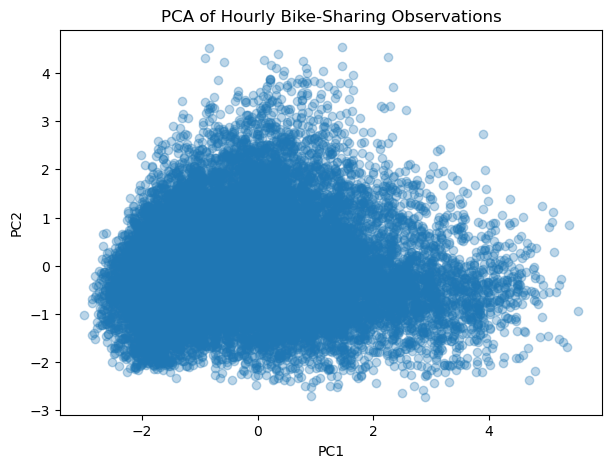

In [10]:
plt.figure(figsize=(7,5))
plt.scatter(Z[:,0], Z[:,1], alpha=0.3)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Hourly Bike-Sharing Observations')
plt.show()

In [11]:
loadings = pd.DataFrame({
    'feature': pca_features,
    'PC1': pca.components_[0],
    'PC2': pca.components_[1]
})

loadings

,feature,PC1,PC2
0,hr,0.396571,0.154484
1,workingday,-0.061091,-0.043781
2,temp,0.364233,-0.509923
3,hum,-0.384045,-0.456507
4,windspeed,0.186011,0.667473
5,casual,0.531373,-0.185084
6,registered,0.491819,-0.161311


In [12]:
import numpy as np
import pandas as pd

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report, roc_auc_score

In [44]:


df["hr_sin"] = np.sin(2 * np.pi * df["hr"] / 24)
df["hr_cos"] = np.cos(2 * np.pi * df["hr"] / 24)
df["mnth_sin"] = np.sin(2 * np.pi * df["mnth"] / 12)
df["mnth_cos"] = np.cos(2 * np.pi * df["mnth"] / 12)

features = [
    'season',
    'mnth_sin',
    'mnth_cos',
    'weathersit',
    'temp',
    'atemp',
    'hum',
    'windspeed'
]

X = df[features]

y = df['high_demand']

In [55]:
from sklearn.model_selection import TimeSeriesSplit, GridSearchCV

y_binary = (y == 'High').astype(int)

split_index = int(0.75 * len(df))

X_train = X.iloc[:split_index]
X_test = X.iloc[split_index:]

y_train = y.iloc[:split_index]
y_test = y.iloc[split_index:]
tscv = TimeSeriesSplit(n_splits=5)

In [56]:
elastic_logit_pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('model', LogisticRegression(
        penalty='elasticnet',
        solver='saga',
        max_iter=10000,
        random_state=0
    ))
])

In [57]:
param_grid = {
    'model__C': [0.01, 0.1, 1, 10, 100],
    'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9]
}

In [59]:
grid = GridSearchCV(
    elastic_logit_pipe,
    param_grid,
    cv=tscv,
    scoring='accuracy'
)

grid.fit(X_train, y_train)

GridSearchCV(cv=TimeSeriesSplit(gap=0, max_train_size=None, n_splits=5, test_size=None),
             estimator=Pipeline(steps=[('scaler', StandardScaler()),
                                       ('model',
                                        LogisticRegression(max_iter=10000,
                                                           penalty='elasticnet',
                                                           random_state=0,
                                                           solver='saga'))]),
             param_grid={'model__C': [0.01, 0.1, 1, 10, 100],
                         'model__l1_ratio': [0.1, 0.25, 0.5, 0.75, 0.9]},
             scoring='accuracy')

In [60]:
grid.best_params_

{'model__C': 0.1, 'model__l1_ratio': 0.1}

In [61]:
y_pred = grid.predict(X_test)
y_prob = grid.predict_proba(X_test)[:, 1]

In [62]:
accuracy = accuracy_score(y_test, y_pred)
accuracy

0.7231300345224396

In [63]:
confusion_matrix(y_test, y_pred)

array([[1806,  910],
       [ 293, 1336]])

In [38]:
auc = roc_auc_score(y_test, y_prob)
auc

np.float64(0.7937589447884488)

In [64]:
results = pd.DataFrame({
    'Metric': ['Accuracy', 'ROC AUC'],
    'Value': [accuracy, auc]
})

results

,Metric,Value
0,Accuracy,0.723130
1,ROC AUC,0.793759


In [65]:
best_model = grid.best_estimator_.named_steps['model']

coef_table = pd.DataFrame({
    'feature': features,
    'coefficient': best_model.coef_[0]
})

coef_table['abs_coefficient'] = coef_table['coefficient'].abs()

coef_table.sort_values('abs_coefficient', ascending=False)

,feature,coefficient,abs_coefficient
4,temp,-0.966752,0.966752
6,hum,0.695493,0.695493
5,atemp,-0.584463,0.584463
1,mnth_sin,-0.527716,0.527716
2,mnth_cos,-0.523583,0.523583
0,season,-0.334295,0.334295
7,windspeed,-0.039082,0.039082
3,weathersit,-0.001836,0.001836


In [42]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(
    n_estimators=500,
    random_state=0
)

rf.fit(X_train, y_train)

rf_pred = rf.predict(X_test)
rf_prob = rf.predict_proba(X_test)[:, 1]

rf_accuracy = accuracy_score(y_test, rf_pred)
rf_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest Accuracy:", rf_accuracy)
print("Random Forest AUC:", rf_auc)

Random Forest Accuracy: 0.706789413118527
Random Forest AUC: 0.7810608485196969


In [27]:
rf_importance = pd.DataFrame({
    'feature': features,
    'importance': rf.feature_importances_
}).sort_values('importance', ascending=False)

rf_importance

,feature,importance
5,hum,0.263653
6,windspeed,0.196452
4,atemp,0.167806
3,temp,0.162874
1,mnth,0.108729
2,weathersit,0.051293
0,season,0.049193


In [28]:
comparison = pd.DataFrame({
    'Model': ['Elastic Net Logistic Regression', 'Random Forest'],
    'Accuracy': [accuracy, rf_accuracy],
    'ROC AUC': [auc, rf_auc]
})

comparison

,Model,Accuracy,ROC AUC
0,Elastic Net Logistic Regression,0.739010,0.807066
1,Random Forest,0.761105,0.836322
